## Experiments

In [8]:
# Set system path

from pathlib import Path
import sys


def find_repo_root(start: Path | None = None) -> Path:
    p = (start or Path.cwd()).resolve()
    for d in (p, *p.parents):
        if (d / ".git").exists() or (d / "pyproject.toml").exists() or (d / "src").exists():
            return d
    return p  # fallback


repo_root = find_repo_root()
print(repo_root)

# This repo uses a "src layout" (the Python package lives in <repo>/src/qlsas),
# but the repo is not installed as a package. Add <repo>/src to sys.path.
src_dir = repo_root / "src"
if src_dir.exists() and str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

# Also add the repo root so you can import top-level modules like
# `linear_systems_problems.random_matrix_generator`.
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

/Users/adrianharkness/QCOL_COPT/HHL/QLSAs


In [9]:
# Import QLSAs modules

from qlsas.algorithms.hhl import HHL, MCRYEigOracle, ExactReciprocalEigOracle, UCRYEigOracle
from qlsas.state_prep import DefaultStatePrep
from qlsas.readout import MeasureXReadout
from qlsas.transpiler import Transpiler
from qlsas.executer import Executer
from qlsas.solver import QuantumLinearSolver
from qlsas.refiner import Refiner
from linear_systems_problems.random_matrix_generator_v2 import generate_problem

# Import other modules
from datetime import datetime
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error

%config InlineBackend.figure_format = "retina"

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

In [10]:
n = 8
prob = generate_problem(n=n, cond_number=5, sparsity=0.5, seed=0)
A, b = prob["A"], prob["b"]

A  = A / np.linalg.norm(b)
b = b / np.linalg.norm(b)

print(f"A: {A}")
print()
print(f"b: {b}")
print()
print(f"min eigenvalue: {np.min(np.linalg.eigvalsh(A))}")
print(f"max eigenvalue: {np.max(np.linalg.eigvalsh(A))}")
print(f"condition number: {np.linalg.cond(A)}")
print(f"sparsity: {np.sum(A != 0) / (n * n)}")

A: [[ 0.52538022 -0.0439178   0.          0.00829532  0.         -0.10924848
  -0.06349057  0.        ]
 [-0.0439178   0.93592011 -0.14125997 -0.12510917  0.         -0.25009028
   0.          0.        ]
 [ 0.         -0.14125997  0.78491068  0.19010648 -0.1075243   0.
   0.          0.12855131]
 [ 0.00829532 -0.12510917  0.19010648  0.98269082  0.07258256  0.
   0.          0.        ]
 [ 0.          0.         -0.1075243   0.07258256  0.42955548  0.
   0.         -0.02651726]
 [-0.10924848 -0.25009028  0.          0.          0.          0.60008524
   0.20926252  0.        ]
 [-0.06349057  0.          0.          0.          0.          0.20926252
   0.43665649  0.        ]
 [ 0.          0.          0.12855131  0.         -0.02651726  0.
   0.          0.80317254]]

b: [ 0.05661294 -0.44772527 -0.55505065 -0.27563635  0.13259855 -0.60797852
 -0.12596272 -0.09588316]

min eigenvalue: 0.2522070291528656
max eigenvalue: 1.261035145764326
condition number: 4.999999999999999
sparsity: 0

In [11]:
oracle = UCRYEigOracle()

backend = AerSimulator()

In [ ]:
iterations = 10 #15          # number of IR iterations to plot
max_qpe_qubits = int(math.log2(len(b)) + 1)  # sweep num_qpe_qubits = 1..max_qpe_qubits

target_successful = int(1e3)  # also passed to the solver below

# rows: qpe qubits, cols: IR iteration
qpe_residuals       = np.full((max_qpe_qubits, iterations), np.nan, dtype=float)
total_circuit_depth = np.full((max_qpe_qubits, iterations), np.nan, dtype=float)
total_cost          = np.full((max_qpe_qubits, iterations), np.nan, dtype=float)
# total_cost[m, k] = sum_{i<=k}  depth_i  *  (target_successful / success_rate_i)
# i.e. the "ideal" number of gate-executions to collect target_successful
# successes per iteration — independent of shots_per_batch overshoot.

for qpe_qubits in range(1, max_qpe_qubits + 1):
    print(f"================num_qpe_qubits: {qpe_qubits}=================")

    hhl = HHL(
    num_qpe_qubits = qpe_qubits,
    eig_oracle = oracle
    )
    
    solver = QuantumLinearSolver(
        qlsa=hhl,
        readout=MeasureXReadout(),
        backend=backend,
        target_successful_shots=target_successful,
        shots_per_batch=int(5*1e3)
    )

    refiner = Refiner(A=A, b=b, solver=solver)
    refined_solution = refiner.refine(precision=1e-20, max_iter=iterations-1, plot=False)
    
    r = np.asarray(refined_solution["residuals"], dtype=float)
    qpe_residuals[qpe_qubits - 1, : len(r)] = r

    circuits      = refined_solution["transpiled_circuits"]
    depths        = np.array([tc.depth() for tc in circuits], dtype=float)
    success_rates = np.array(
        [s["success_probability"] for s in refined_solution["shot_stats"]],
        dtype=float,
    )
    # Ideal shots needed to hit target_successful at this success rate
    # (not actual shots submitted — that's polluted by shots_per_batch overshoot).
    ideal_shots = target_successful / np.maximum(success_rates, 1e-12)

    cumulative_depth = np.cumsum(depths)
    cumulative_cost  = np.cumsum(depths * ideal_shots)

    n_steps = min(len(cumulative_depth), iterations)
    total_circuit_depth[qpe_qubits - 1, :n_steps] = cumulative_depth[:n_steps]
    total_cost[qpe_qubits - 1, :n_steps]          = cumulative_cost[:n_steps]

# heatmap of log10 residuals
log_qpe_residuals = np.log10(np.maximum(qpe_residuals, 1e-16))
log_total_depth   = np.log10(np.maximum(total_circuit_depth, 1))
log_total_cost    = np.log10(np.maximum(total_cost, 1))

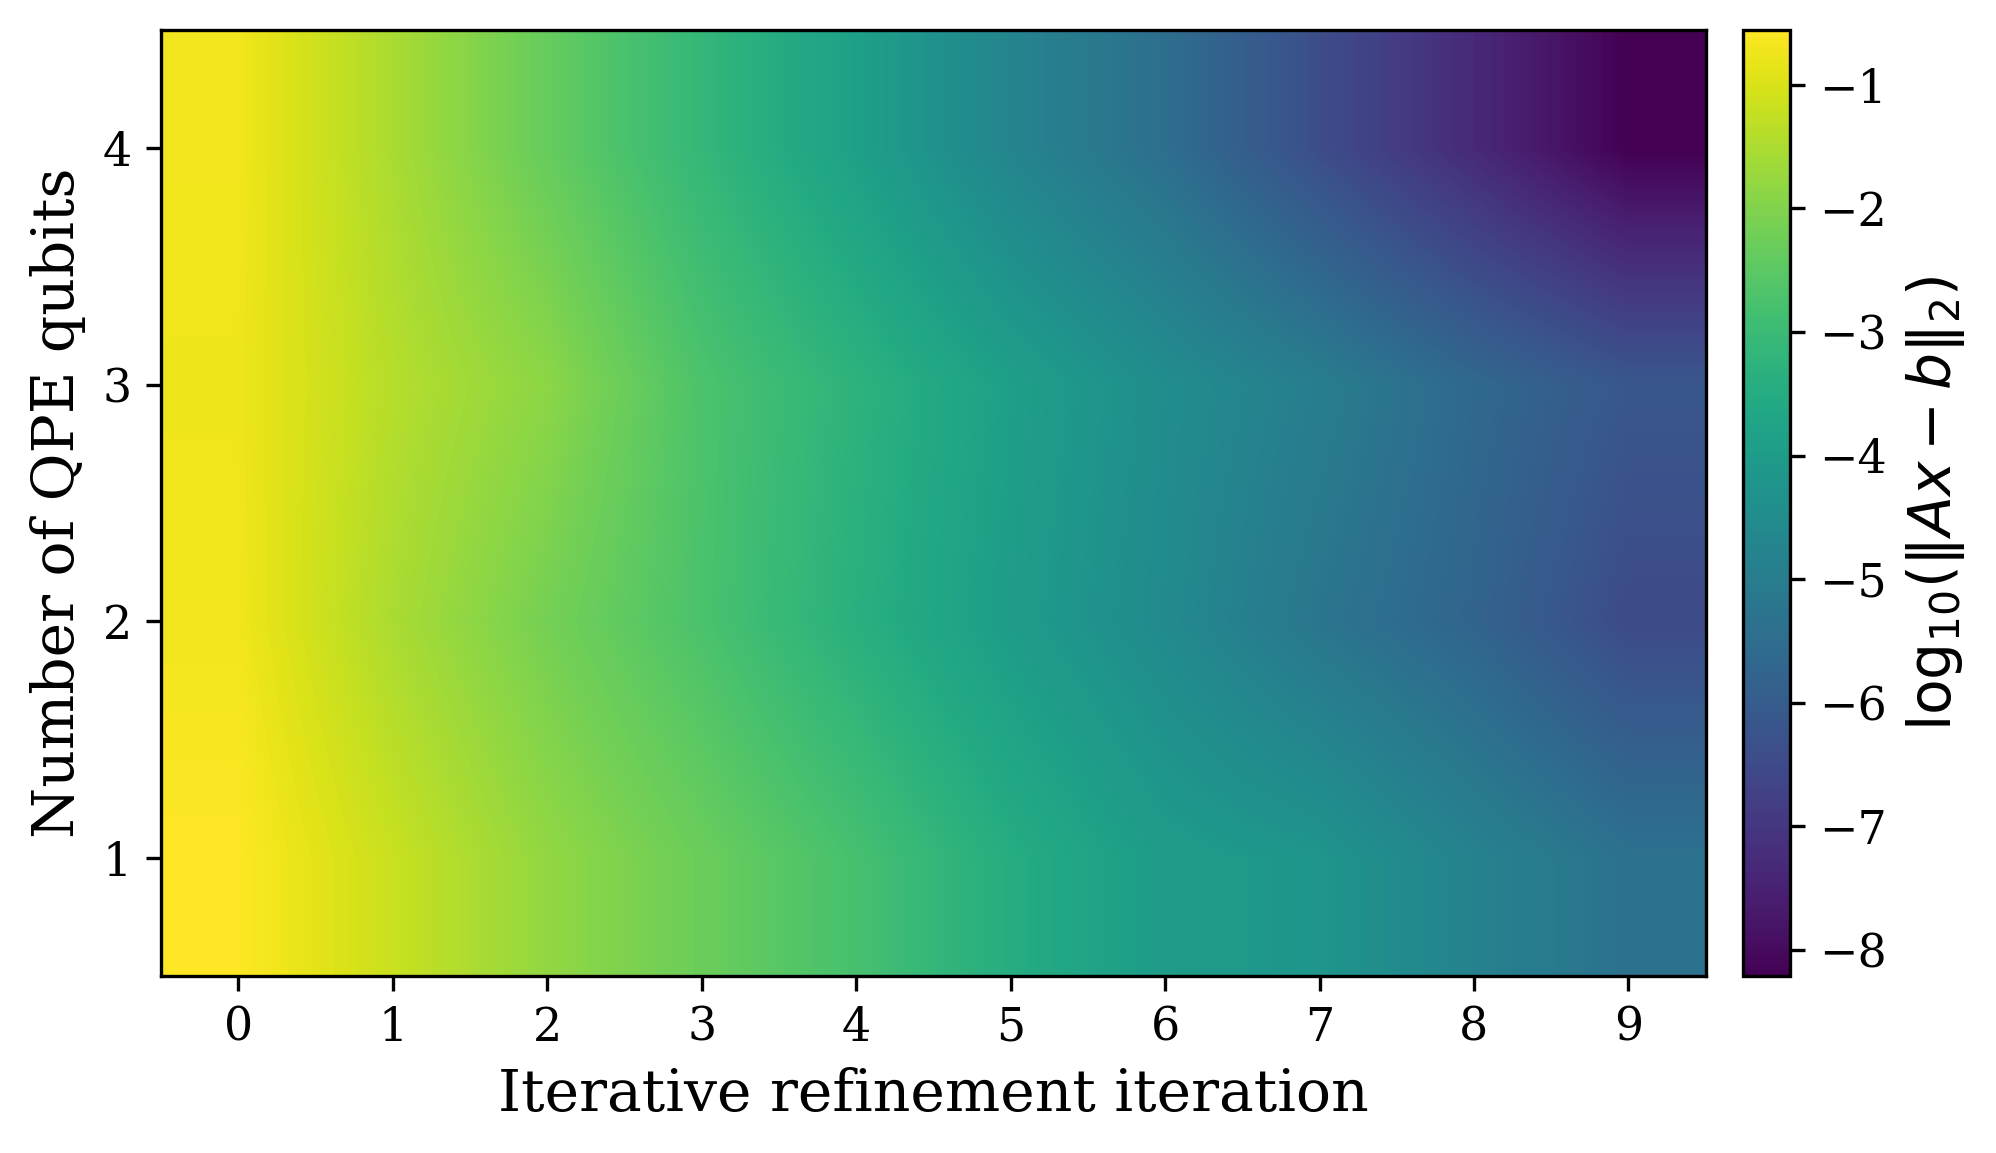

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(
    log_qpe_residuals,
    origin="lower",
    aspect="auto",
    cmap="viridis",
    interpolation="bilinear",
)

ax.set_xlabel("Iterative refinement iteration")
ax.set_ylabel("Number of QPE qubits")

ax.set_xticks(np.arange(total_circuit_depth.shape[1]))
ax.set_yticks(np.arange(total_circuit_depth.shape[0]))
ax.set_yticklabels(np.arange(1, total_circuit_depth.shape[0] + 1))

cbar = fig.colorbar(im, ax=ax, pad=0.02)
cbar.set_label(r"$\log_{10}\!\left(\|Ax - b\|_2\right)$")
cbar.ax.tick_params(labelsize=11)

X, Y = np.meshgrid(np.arange(total_circuit_depth.shape[1]), np.arange(total_circuit_depth.shape[0]))
cs = ax.contour(X, Y, total_circuit_depth, levels=[100000, 200000, 400000, 800000],
                colors="white", linestyles="--", linewidths=0.9)
labels = ax.clabel(cs, fmt=lambda v: f"{int(v):,}", fontsize=9, colors="white")
outline = [pe.withStroke(linewidth=2, foreground="black")]
for lbl in labels:
    lbl.set_path_effects(outline)

# ax.plot([], [], ls="--", color="gray", label="Cumulative circuit depth")
# ax.legend(loc="upper right", facecolor="white", framealpha=1.0, edgecolor="gray")

plt.tight_layout()
plt.savefig(f"../data/{n}var_qpe_vs_ir_residuals_without_overlay_cond_{prob['condition_number']:.2f}_{backend.name}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pdf")
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(
    log_total_cost,
    origin="lower",
    aspect="auto",
    cmap="magma",
    interpolation="nearest",
)

ax.set_xlabel("Iterative refinement iteration")
ax.set_ylabel("Number of QPE qubits")

ax.set_xticks(np.arange(total_cost.shape[1]))
ax.set_yticks(np.arange(total_cost.shape[0]))
ax.set_yticklabels(np.arange(1, total_cost.shape[0] + 1))

cbar = fig.colorbar(im, ax=ax)
cbar.set_label(
    r"$\log_{10}\!\left(\sum_i \mathrm{depth}_i \cdot "
    r"\frac{\mathrm{target\_successful}}{\mathrm{success\_rate}_i}\right)$"
)

plt.tight_layout()
plt.savefig(f"../data/{n}var_qpe_vs_ir_total_cost_cond_{prob['condition_number']:.2f}_{backend.name}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pdf")
plt.show()

In [ ]:
iterations = 10 #11          # number of IR iterations to plot (0..iterations-1)
shots = np.linspace(1, 1000, 11, dtype=int)

# rows: shot counts, cols: IR iteration
shot_residuals = np.full((len(shots), iterations), np.nan, dtype=float)

num_qpe_qubits = int(math.log2(len(b)))

hhl = HHL(
    num_qpe_qubits = num_qpe_qubits,
    eig_oracle = oracle
)

for i, shot_count in enumerate(shots):
    print(f"================shots: {shot_count}=================")
    solver = QuantumLinearSolver(
        qlsa=hhl,
        readout=MeasureXReadout(),
        backend=backend,
        target_successful_shots=shot_count,
        shots_per_batch=5 * shot_count
    )

    refiner = Refiner(A=A, b=b, solver=solver)
    refined_solution = refiner.refine(precision=1e-20, max_iter=iterations-1, plot=False)

    r = np.asarray(refined_solution["residuals"], dtype=float)
    shot_residuals[i, : len(r)] = r

# heatmap of log10 residuals
log_shot_residuals = np.log10(np.maximum(shot_residuals, 1e-16))

================shots: 1=================
IR Iteration: 0
>>> Job ID: 0d2c1ba3-f0cd-463a-b257-f1f5bb11f9f5
>>> Job Status: DONE      
>>> Job ID: 542c02bc-6ab5-47c0-aa62-c5b3f0dbaa16
>>> Job Status: DONE      
  residual: 0.9109, error: 0.7146, alpha: 0.5966

IR Iteration: 1
>>> Job ID: 2a75837d-e498-4c1e-bdd8-0e2b8912b3b7
>>> Job Status: DONE      
>>> Job ID: 662eb132-df1f-4ae5-b6b8-2a9e2fdbfe68
>>> Job Status: DONE      
  residual: 0.8243, error: 0.4708, alpha: 0.4307

IR Iteration: 2
>>> Job ID: 70fc739d-82ad-4202-801e-c12284175434
>>> Job Status: DONE      
  residual: 0.7957, error: 0.4974, alpha: 0.3774

IR Iteration: 3
>>> Job ID: 8c3178f0-f67f-403e-9476-bbc6a06f8813
>>> Job Status: DONE      
  residual: 0.7867, error: 0.4746, alpha: 0.1519

IR Iteration: 4
>>> Job ID: 807d474b-bc56-471c-bec9-7fa879c98498
>>> Job Status: DONE      
>>> Job ID: a5a2c99d-afc7-428c-9b9c-5a923d38953a
>>> Job Status: DONE      
>>> Job ID: 42649dfd-c69d-4a6e-b385-792765fabe52
>>> Job Status: DONE 

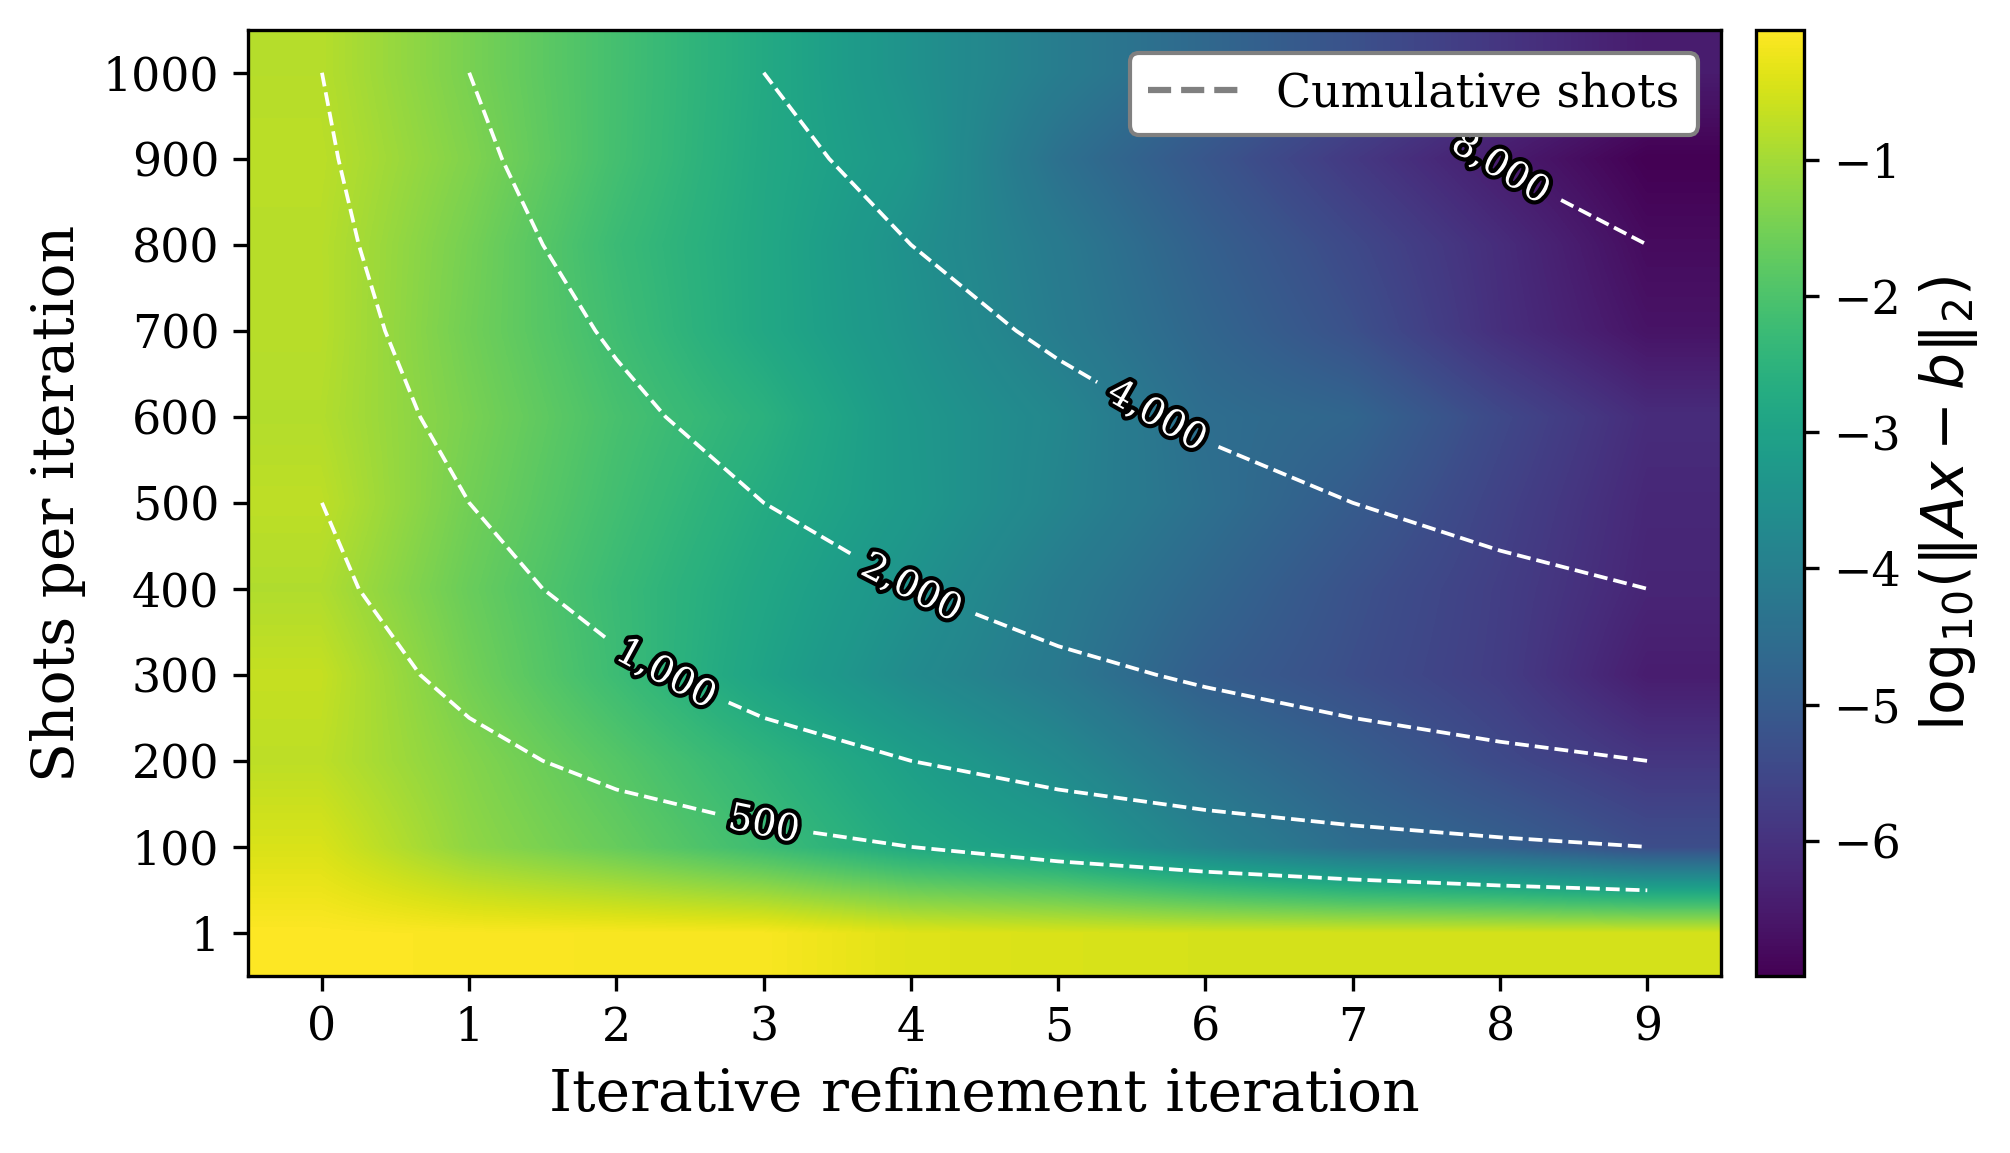

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(
    log_shot_residuals,
    origin="lower",
    aspect="auto",
    cmap="viridis",
    interpolation="bilinear",
)

ax.set_xlabel("Iterative refinement iteration")
ax.set_ylabel("Shots per iteration")

ax.set_xticks(np.arange(iterations))
ax.set_yticks(np.arange(len(shots)))
ax.set_yticklabels(shots)

cbar = fig.colorbar(im, ax=ax, pad=0.02)
cbar.set_label(r"$\log_{10}\!\left(\|Ax - b\|_2\right)$")
cbar.ax.tick_params(labelsize=11)

X, Y = np.meshgrid(np.arange(iterations), np.arange(len(shots)))
cumulative_shots = shots[:, None] * (X + 1)
levels = [500, 1000, 2000, 4000, 8000]
cs = ax.contour(X, Y, cumulative_shots, levels=levels,
                colors="white", linestyles="--", linewidths=0.9)
labels = ax.clabel(cs, fmt=lambda v: f"{int(v):,}", fontsize=9, colors="white")
outline = [pe.withStroke(linewidth=2, foreground="black")]
for lbl in labels:
    lbl.set_path_effects(outline)

ax.plot([], [], ls="--", color="gray", label="Cumulative shots")
ax.legend(loc="upper right", facecolor="white", framealpha=1.0, edgecolor="gray")

plt.tight_layout()
plt.savefig(f"../data/{n}var_shots_vs_ir_residuals_with_overlay_{backend.name}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pdf")
plt.show()

In [ ]:
# max_qpe_qubits = 6
# shot_values = np.linspace(1, 200, 21, dtype=int)

# single_solve_residuals = np.full((max_qpe_qubits, len(shot_values)), np.nan, dtype=float)

# prob = generate_problem(n=n, cond_number=5.0, sparsity=0.5, seed=0)
# A, b = prob["A"], prob["b"]
# A = A / np.linalg.norm(b)
# b = b / np.linalg.norm(b)
# x_classical = np.linalg.solve(A, b)

# for qi, qpe_qubits in enumerate(range(1, max_qpe_qubits + 1)):
#     for si, shot_count in enumerate(shot_values):
#         print(f"qpe={qpe_qubits}, shots={shot_count}")
#         solver = QuantumLinearSolver(
#             qlsa=HHL(
#                 state_prep=DefaultStatePrep(),
##                 num_qpe_qubits=qpe_qubits,
#                 eig_oracle = oracle
#             ),
#             backend=AerSimulator(),
#             target_successful_shots=int(shot_count),
#             shots_per_batch=5 * int(shot_count),
#             optimization_level=3,
#             executer=executer,
#             post_processor=processor,
#         )
#         x_q = solver.solve(A, b, verbose=False)
#         alpha = np.dot(A @ x_q, b) / np.dot(A @ x_q, A @ x_q)
#         x_scaled = alpha * x_q
#         single_solve_residuals[qi, si] = np.linalg.norm(b - A @ x_scaled)

# log_single_residuals = np.log10(np.maximum(single_solve_residuals, 1e-16))

In [ ]:
# fig, ax = plt.subplots(figsize=(7, 4))
# im = ax.imshow(
#     single_solve_residuals,
#     origin="lower",
#     aspect="auto",
#     cmap="viridis",
#     interpolation="nearest",
# )

# ax.set_xlabel("Shots")
# ax.set_ylabel("Number of QPE qubits")

# ax.set_xticks(np.arange(len(shot_values)))
# ax.set_xticklabels(shot_values, rotation=45, ha="right")
# ax.set_yticks(np.arange(max_qpe_qubits))
# ax.set_yticklabels(np.arange(1, max_qpe_qubits + 1))

# cbar = fig.colorbar(im, ax=ax, pad=0.02)
# cbar.set_label(r"$\log_{10}\!\left(\|Ax - b\|_2\right)$")
# cbar.ax.tick_params(labelsize=11)

# plt.tight_layout()
# # plt.savefig("qpe_vs_shots_residuals.pdf")
# plt.show()

In [ ]:
# from matplotlib.colors import ListedColormap

# converges = single_solve_residuals < .5

# cmap_rg = ListedColormap(["#d62728", "#2ca02c"])

# fig, ax = plt.subplots(figsize=(7, 4))
# im = ax.imshow(
#     converges.astype(int),
#     origin="lower",
#     aspect="auto",
#     cmap=cmap_rg,
#     interpolation="nearest",
#     vmin=0,
#     vmax=1,
# )

# ax.set_xlabel("Shots")
# ax.set_ylabel("Number of QPE qubits")

# ax.set_xticks(np.arange(len(shot_values)))
# ax.set_xticklabels(shot_values, rotation=45, ha="right")
# ax.set_yticks(np.arange(max_qpe_qubits))
# ax.set_yticklabels(np.arange(1, max_qpe_qubits + 1))

# from matplotlib.patches import Patch
# legend_handles = [
#     Patch(facecolor="#2ca02c", edgecolor="gray", label=r"$\|r\| < 1$ (IR will converge)"),
#     Patch(facecolor="#d62728", edgecolor="gray", label=r"$\|r\| \geq 1$ (IR will not converge)"),
# ]
# ax.legend(handles=legend_handles, loc="upper left", facecolor="white", framealpha=1.0, edgecolor="gray")

# plt.tight_layout()
# # plt.savefig("qpe_vs_shots_convergence.pdf")
# plt.show()

### Sensitivity analysis: problem size and condition number

In [ ]:
sizes = [4, 8, 16]
cond = 5
max_iter = 10
precision = 1e-15

size_results = {}

for n in sizes:
    print(f"================ n={n} ==================")
    prob = generate_problem(n=n, cond_number=cond, sparsity=0.5, seed=0)
    A, b = prob["A"], prob["b"]
    A = A / np.linalg.norm(b)
    b = b / np.linalg.norm(b)

    hhl = HHL(,
        num_qpe_qubits=int(math.log2(n)),
        eig_oracle=oracle,
    )
    solver = QuantumLinearSolver(
        qlsa=hhl,
        readout=MeasureXReadout(),
        backend=backend,
        target_successful_shots=1000,
        shots_per_batch=5000,
    )
    refiner = Refiner(A=A, b=b, solver=solver)
    result = refiner.refine(precision=precision, max_iter=max_iter, plot=False, verbose=False)
    size_results[n] = result["residuals"]
    print(f"  converged in {result['total_iterations']} iterations")

================ n=4 ==================
  converged in 11 iterations
================ n=8 ==================
  converged in 11 iterations
================ n=16 ==================
  converged in 11 iterations


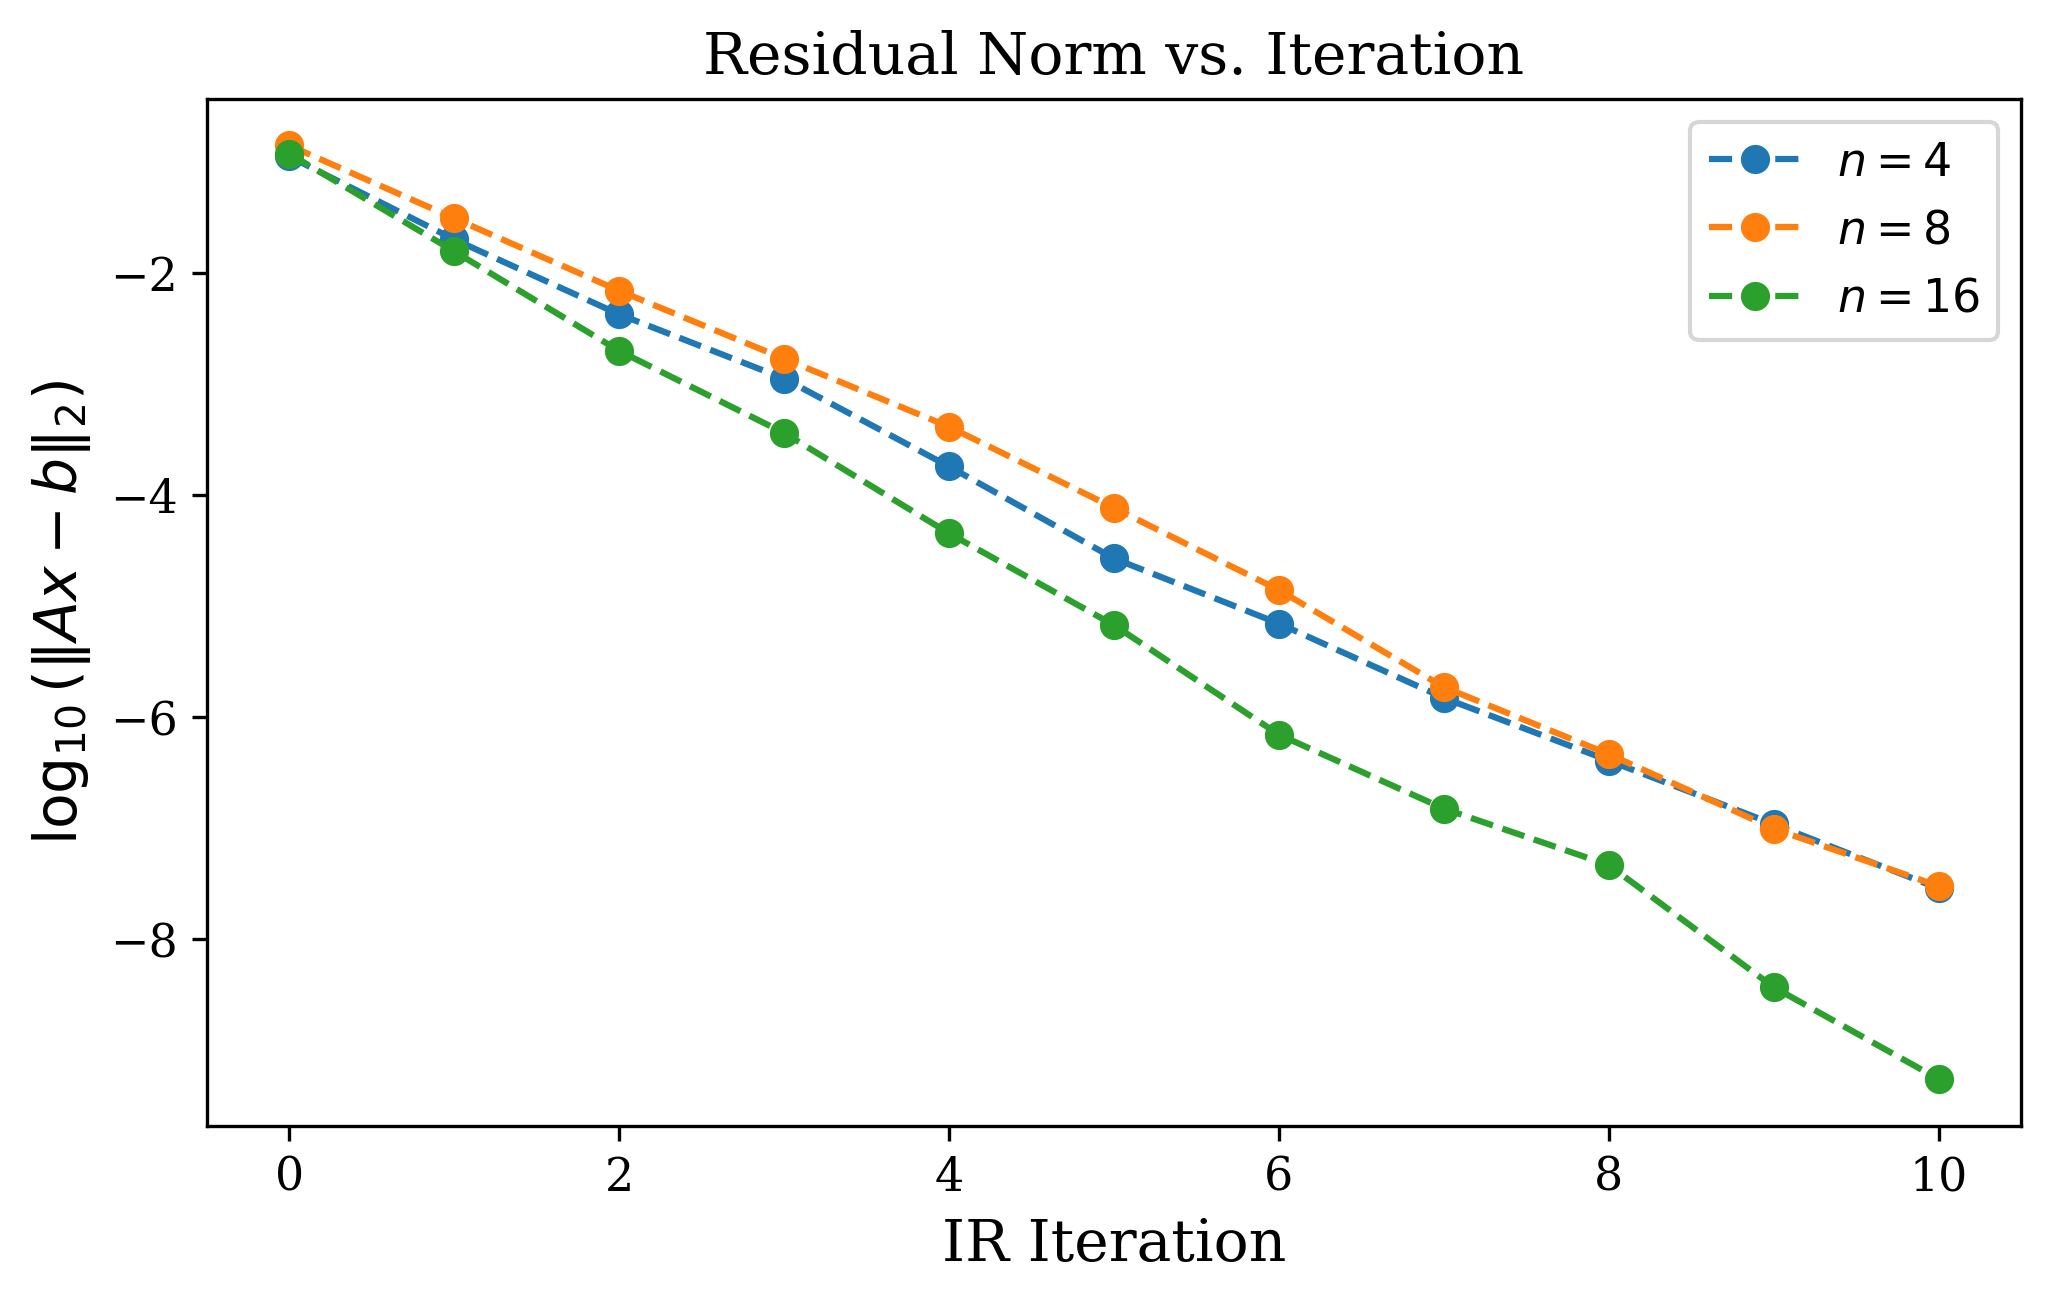

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))

for n, residuals in size_results.items():
    iters = np.arange(len(residuals))
    ax.plot(iters, [np.log10(r) for r in residuals], "o--", label=f"$n = {n}$")

ax.set_xlabel("IR Iteration")
ax.set_ylabel(r"$\log_{10}(\|Ax - b\|_2)$")
ax.set_title("Residual Norm vs. Iteration")
ax.legend()
plt.tight_layout()
plt.savefig(f"../data/sensitivity_problem_size_kappa{cond}_{backend.name}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pdf")
plt.show()

In [ ]:
cond_numbers = [10, 20, 30]
n = 8
max_iter = 10
precision = 1e-15

cond_results = {}

for cond in cond_numbers:
    print(f"================ kappa={cond} ==================")
    prob = generate_problem(n=n, cond_number=cond, sparsity=0.5, seed=0)
    A, b = prob["A"], prob["b"]
    A = A / np.linalg.norm(b)
    b = b / np.linalg.norm(b)

    hhl = HHL(,
        num_qpe_qubits=int(math.log2(n)),
        eig_oracle=oracle,
    )
    solver = QuantumLinearSolver(
        qlsa=hhl,
        readout=MeasureXReadout(),
        backend=backend,
        target_successful_shots=1000,
        shots_per_batch=5000,
    )
    refiner = Refiner(A=A, b=b, solver=solver)
    result = refiner.refine(precision=precision, max_iter=max_iter, plot=False, verbose=False)
    cond_results[cond] = result["residuals"]
    print(f"  converged in {result['total_iterations']} iterations")

================ kappa=10 ==================
  converged in 16 iterations
================ kappa=20 ==================
  converged in 16 iterations
================ kappa=30 ==================
  converged in 16 iterations


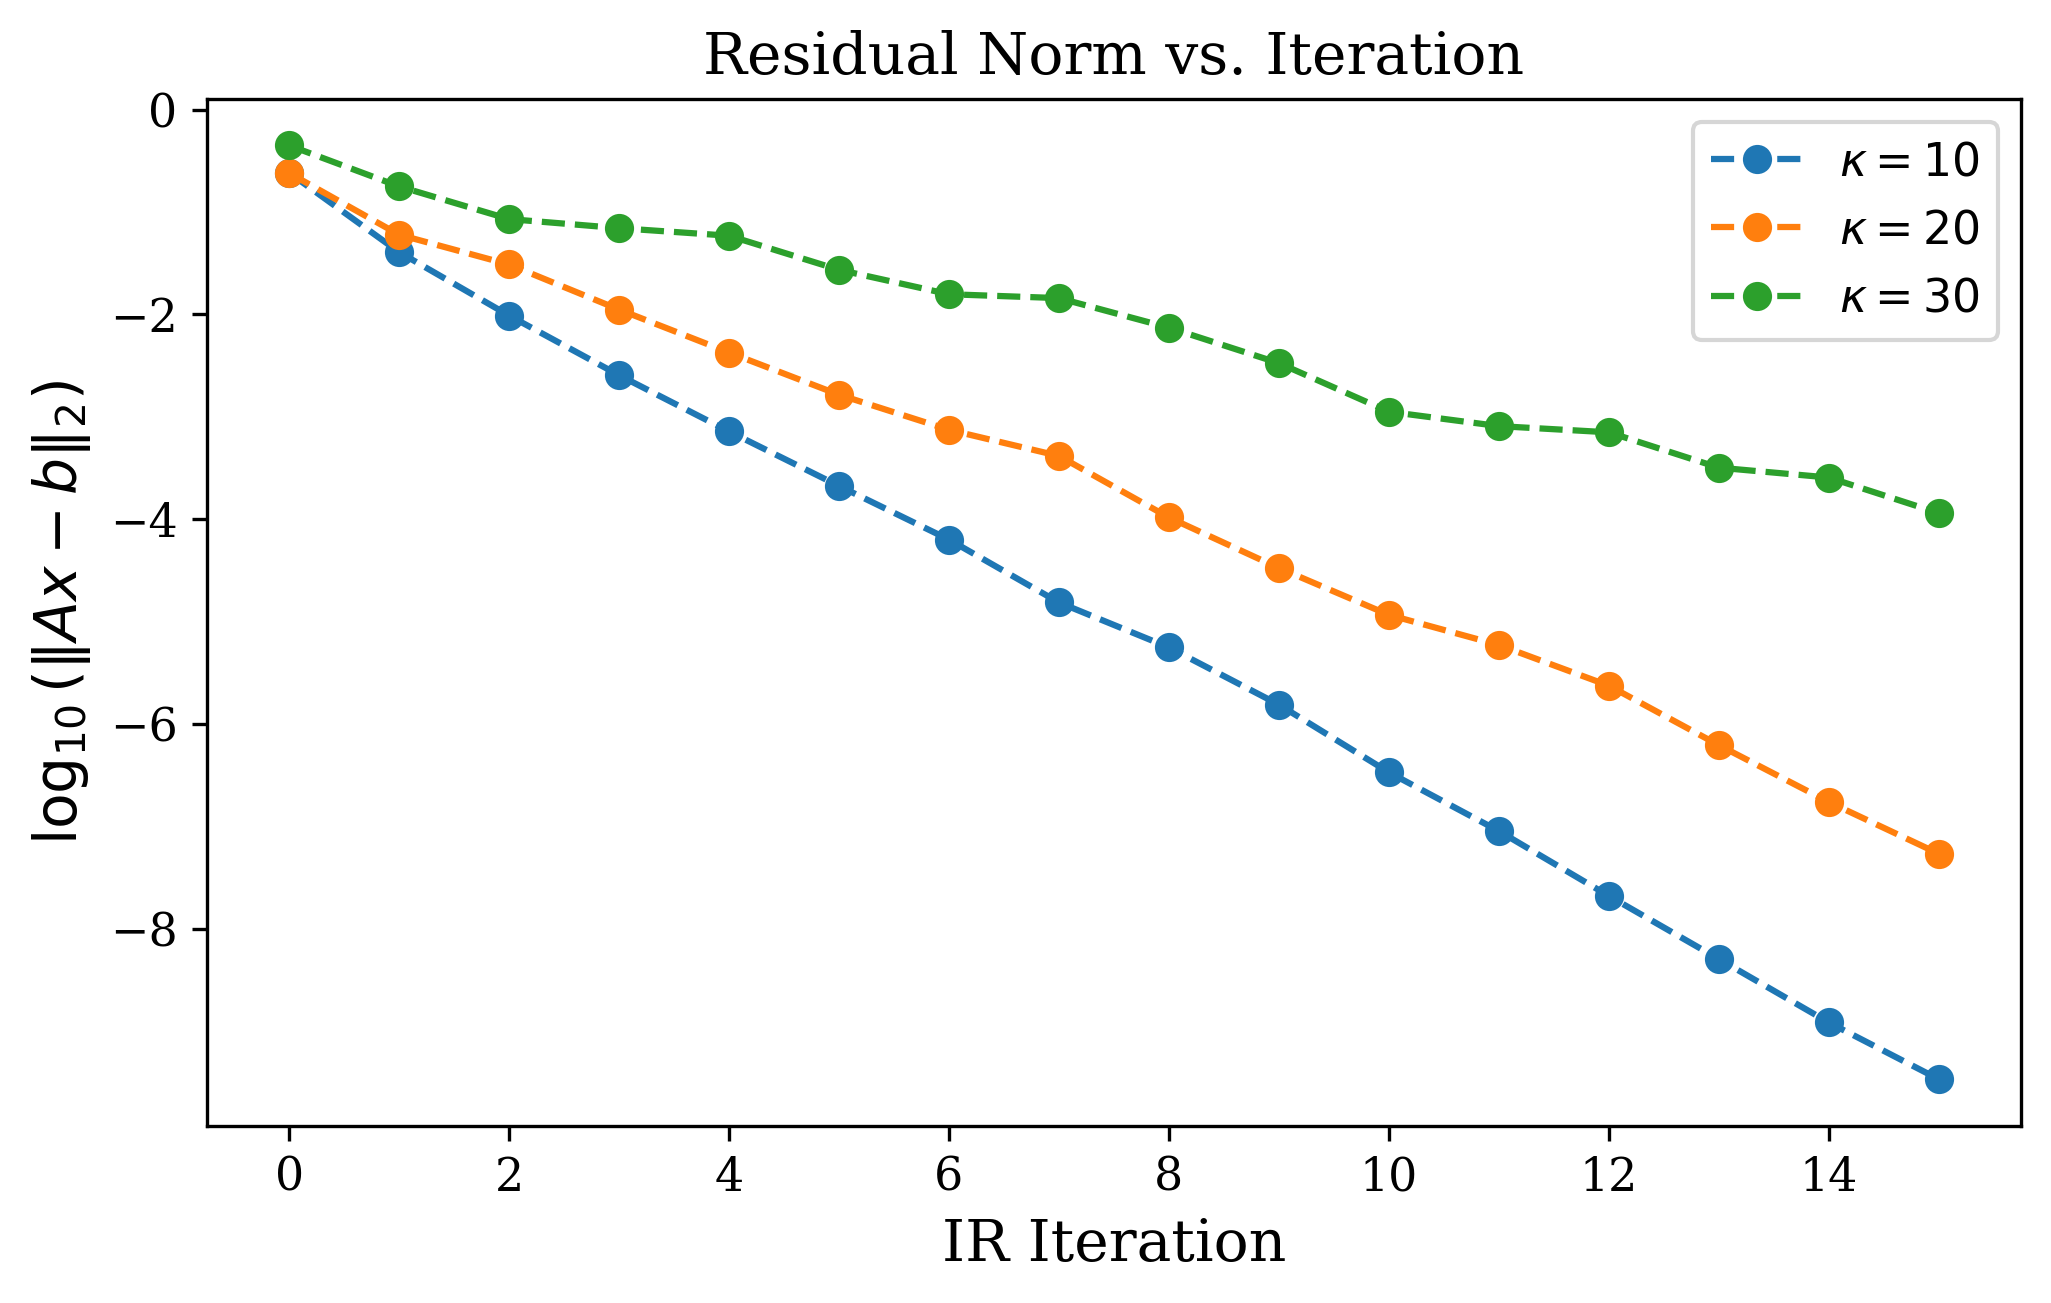

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))

for kappa, residuals in cond_results.items():
    iters = np.arange(len(residuals))
    ax.plot(iters, [np.log10(r) for r in residuals], "o--", label=rf"$\kappa = {kappa}$")

ax.set_xlabel("IR Iteration")
ax.set_ylabel(r"$\log_{10}(\|Ax - b\|_2)$")
ax.set_title("Residual Norm vs. Iteration")
ax.legend()
plt.tight_layout()
plt.savefig(f"../data/sensitivity_cond_number_n{n}_{backend.name}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pdf")
plt.show()